# 50 — EDA: Why Does Merging Peer Data Hurt AUB F1?

**Goal**: Diagnose *exactly* why training on AUB+Lehigh+Marquette+Villanova drops AUB F1  
by ~9 points, and surface actionable signals for recovery strategies.

**Agenda**
| § | Topic | Key Question |
|---|-------|--------------|
| 1 | Dataset overview | How big / balanced is each institution's slice? |
| 2 | Citation & label analysis | Are institution thresholds compatible? |
| 3 | Feature drift | Which features look most different across institutions? |
| 4 | Class separability | Which features predict high-impact *universally*? |
| 5 | Venue metric deep-dive | Are venue signals equally informative everywhere? |
| 6 | Sample weighting ablation | What AUB:peer weight ratio maximises AUB F1? |
| 7 | Error analysis | Which AUB papers does the merged model get wrong? |
| 8 | Recommendations | Concrete fixes ranked by expected gain |

**Input**: `data/processed/all_unis_cleaned.pkl`

In [1]:
import sys
sys.path.append('../../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

FIGURES = Path('../../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

TRAIN_YEARS = [2015, 2016, 2017]
TEST_YEARS  = [2018, 2019, 2020]
PALETTE     = {'AUB': '#2196F3', 'Lehigh': '#FF9800', 'Marquette': '#4CAF50', 'Villanova': '#9C27B0'}

# AUB-only baseline reference
BASELINE_F1 = 0.6255
MERGED_F1   = 0.5356  # Exp 11 result

print('Libraries loaded.')

Libraries loaded.


## 1. Dataset Overview

In [2]:
df = pd.read_pickle('../../data/processed/all_unis_cleaned.pkl')

df_train = df[df['Year'].isin(TRAIN_YEARS)].copy()
df_test  = df[df['Year'].isin(TEST_YEARS)].copy()

INSTS = sorted(df['institution'].unique())
print(f'Total rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Institutions: {INSTS}')
print()
print('Papers per institution per split:')
summary = pd.DataFrame({
    'train': df_train['institution'].value_counts(),
    'test' : df_test['institution'].value_counts(),
    'total': df['institution'].value_counts(),
})
summary['train_pct'] = (summary['train'] / summary['total'] * 100).round(1)
print(summary.to_string())

Total rows: 39,391  |  Columns: 69
Institutions: ['AUB', 'Lehigh', 'Marquette', 'Villanova']

Papers per institution per split:
             train  test  total  train_pct
institution                               
AUB           2545  3573  14832     17.200
Lehigh        1249  2107   9848     12.700
Marquette     1410  1870   8403     16.800
Villanova     1051  1321   6308     16.700


Global merged-train threshold (75th pct): 39 citations
Per-institution 75th pct thresholds (train):
  AUB         : 38 citations   → 25.5% high-impact
  Lehigh      : 44 citations   → 25.9% high-impact
  Marquette   : 40 citations   → 25.2% high-impact
  Villanova   : 37 citations   → 25.2% high-impact


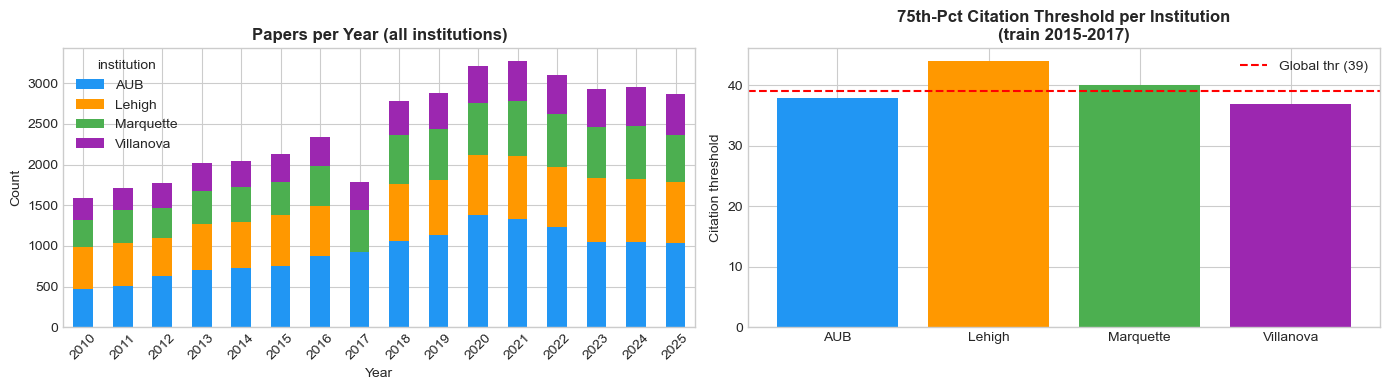

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Papers per year per institution
yr_inst = df.groupby(['Year', 'institution']).size().unstack(fill_value=0)
yr_inst.plot(kind='bar', stacked=True, ax=axes[0],
             color=[PALETTE.get(c, 'grey') for c in yr_inst.columns])
axes[0].set_title('Papers per Year (all institutions)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Class balance per institution
thresholds = {}
pos_rates  = {}
for inst in INSTS:
    sub = df_train[df_train['institution'] == inst]['Citations']
    thr = sub.quantile(0.75)
    thresholds[inst] = thr
    pos_rates[inst]  = (sub >= thr).mean()

# Global threshold (75th pct of all merged train papers)
global_thr = df_train['Citations'].quantile(0.75)
print(f'Global merged-train threshold (75th pct): {global_thr:.0f} citations')
print('Per-institution 75th pct thresholds (train):')
for inst, thr in thresholds.items():
    print(f'  {inst:12s}: {thr:.0f} citations   → {pos_rates[inst]:.1%} high-impact')

inst_thr_df = pd.Series(thresholds).rename('threshold').reset_index()
inst_thr_df.columns = ['institution', 'threshold']
colors_bar = [PALETTE.get(i, 'grey') for i in inst_thr_df['institution']]
axes[1].bar(inst_thr_df['institution'], inst_thr_df['threshold'], color=colors_bar)
axes[1].axhline(global_thr, ls='--', color='red', lw=1.5, label=f'Global thr ({global_thr:.0f})')
axes[1].set_title('75th-Pct Citation Threshold per Institution\n(train 2015-2017)', fontweight='bold')
axes[1].set_ylabel('Citation threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '50_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Citation & Label Compatibility Analysis

If institutions have very different citation distributions, a single threshold makes labels
inconsistent — the model receives contradictory supervision signals.

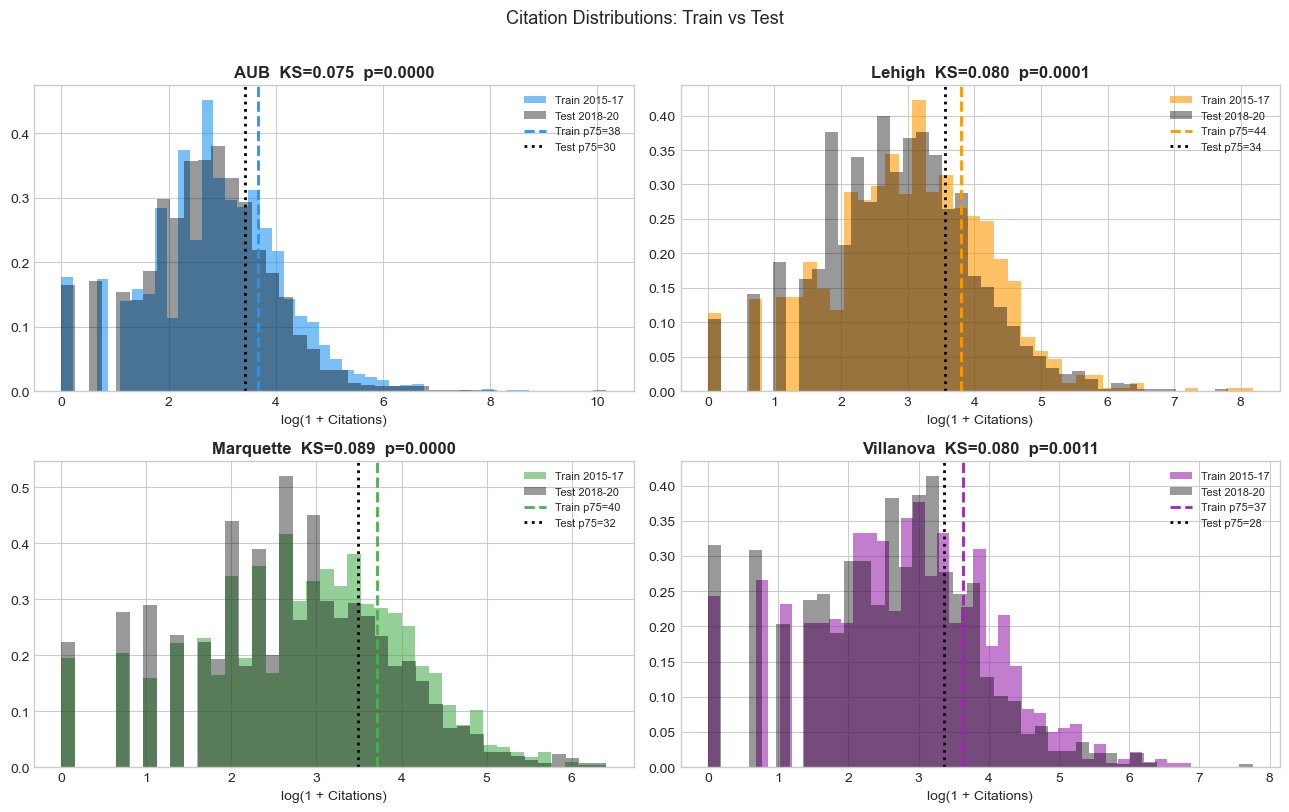

KS Test — Train vs Test citation distribution:
institution  ks_stat  p_value  median_train  median_test  p75_train  p75_test
        AUB    0.075    0.000        17.000       14.000     38.000    30.000
     Lehigh    0.080    0.000        20.000       16.000     44.000    34.000
  Marquette    0.089    0.000        18.000       14.000     40.000    31.750
  Villanova    0.080    0.001        15.000       13.000     37.000    28.000


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

ks_rows = []
for i, inst in enumerate(INSTS):
    tr = df_train[df_train['institution'] == inst]['Citations']
    te = df_test[df_test['institution']   == inst]['Citations']

    stat, pval = ks_2samp(tr.values, te.values)
    ks_rows.append({'institution': inst, 'ks_stat': stat, 'p_value': pval,
                    'median_train': tr.median(), 'median_test': te.median(),
                    'p75_train': tr.quantile(0.75), 'p75_test': te.quantile(0.75)})

    ax = axes[i]
    ax.hist(np.log1p(tr), bins=40, alpha=0.6, density=True,
            color=PALETTE.get(inst, 'grey'), label='Train 2015-17')
    ax.hist(np.log1p(te), bins=40, alpha=0.4, density=True,
            color='black', label='Test 2018-20')
    ax.axvline(np.log1p(tr.quantile(0.75)), color=PALETTE.get(inst,'grey'),
               ls='--', lw=2, label=f'Train p75={tr.quantile(0.75):.0f}')
    ax.axvline(np.log1p(te.quantile(0.75)), color='black',
               ls=':', lw=2, label=f'Test p75={te.quantile(0.75):.0f}')
    ax.set_title(f'{inst}  KS={stat:.3f}  p={pval:.4f}', fontweight='bold')
    ax.set_xlabel('log(1 + Citations)')
    ax.legend(fontsize=8)

plt.suptitle('Citation Distributions: Train vs Test', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '50_citation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

ks_df = pd.DataFrame(ks_rows)
print('KS Test — Train vs Test citation distribution:')
print(ks_df.to_string(index=False))

Label compatibility matrix — % high-impact under each threshold

Row = institution whose papers are labelled
Col = threshold being applied (from that institution's 75th pct)

             AUB  Lehigh  Marquette  Villanova
AUB       25.500  21.600     23.900     26.200
Lehigh    29.500  25.900     28.200     30.300
Marquette 26.800  22.400     25.200     27.700
Villanova 24.600  21.200     23.300     25.200

Diagonal = self-threshold (should all be ~25%)
Large off-diagonal values = label contamination when using global threshold


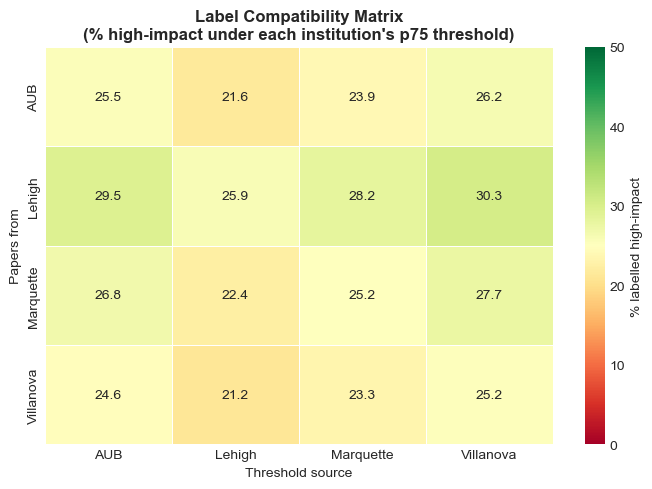

In [5]:
# Label compatibility: what % of each institution's papers would be labelled
# high-impact under *each other institution's* threshold?
print('Label compatibility matrix — % high-impact under each threshold\n')
print('Row = institution whose papers are labelled')
print('Col = threshold being applied (from that institution\'s 75th pct)')
print()

compat = pd.DataFrame(index=INSTS, columns=INSTS, dtype=float)
for row_inst in INSTS:
    cit = df_train[df_train['institution'] == row_inst]['Citations']
    for col_inst in INSTS:
        thr = thresholds[col_inst]
        compat.loc[row_inst, col_inst] = (cit >= thr).mean() * 100

print(compat.round(1).to_string())
print()
print('Diagonal = self-threshold (should all be ~25%)')
print('Large off-diagonal values = label contamination when using global threshold')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(compat.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=50, ax=ax,
            linewidths=0.5, cbar_kws={'label': '% labelled high-impact'})
ax.set_title('Label Compatibility Matrix\n(% high-impact under each institution\'s p75 threshold)', fontweight='bold')
ax.set_xlabel('Threshold source')
ax.set_ylabel('Papers from')
plt.tight_layout()
plt.savefig(FIGURES / '50_label_compatibility.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Drift Analysis

Features that look very different between AUB and peers may push the merged model
toward peer-specific decision boundaries that don't generalise to AUB.

In [22]:
STRUCTURED_FEATURES = {
    'SNIP (publication year)':                     'SNIP',
    'SNIP percentile (publication year) *':        'SNIP percentile',
    'CiteScore (publication year)':                'CiteScore',
    'CiteScore percentile (publication year) *':   'CiteScore pct',
    'SJR (publication year)':                      'SJR',
    'SJR percentile (publication year) *':         'SJR percentile',
    'Topic Prominence Percentile':                 'Topic Prominence',
    'Number of Authors':                           'Num Authors',
    'Number of Institutions':                      'Num Institutions',
    'Number of Countries/Regions':                 'Num Countries',
}

AVAIL_FEATS = {k: v for k, v in STRUCTURED_FEATURES.items() if k in df.columns}
print(f'Available structured features: {len(AVAIL_FEATS)}')
print(list(AVAIL_FEATS.values()))

Available structured features: 10
['SNIP', 'SNIP percentile', 'CiteScore', 'CiteScore pct', 'SJR', 'SJR percentile', 'Topic Prominence', 'Num Authors', 'Num Institutions', 'Num Countries']


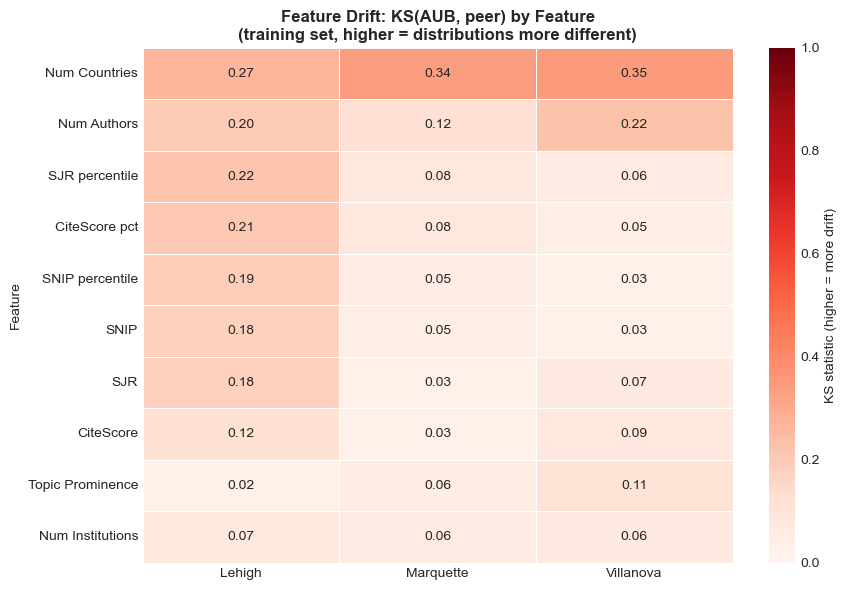

Top features by max drift across peers:
peer              max_drift
feature                    
Num Countries         0.349
Num Authors           0.224
SJR percentile        0.216
CiteScore pct         0.207
SNIP percentile       0.189
SNIP                  0.177
SJR                   0.176
CiteScore             0.124
Topic Prominence      0.106
Num Institutions      0.073


In [7]:
# KS test: each peer institution vs AUB (training set)
aub_train = df_train[df_train['institution'] == 'AUB']

drift_rows = []
for col, short_name in AVAIL_FEATS.items():
    aub_vals = pd.to_numeric(aub_train[col], errors='coerce').dropna()
    for peer in [i for i in INSTS if i != 'AUB']:
        peer_vals = pd.to_numeric(
            df_train[df_train['institution'] == peer][col], errors='coerce'
        ).dropna()
        if len(peer_vals) < 10:
            continue
        stat, pval = ks_2samp(aub_vals, peer_vals)
        drift_rows.append({
            'feature':      short_name,
            'peer':         peer,
            'ks_stat':      round(stat, 3),
            'p_value':      round(pval, 4),
            'aub_median':   round(aub_vals.median(), 3),
            'peer_median':  round(peer_vals.median(), 3),
            'median_ratio': round(peer_vals.median() / (aub_vals.median() + 1e-9), 2),
        })

drift_df = pd.DataFrame(drift_rows)

# Pivot: feature × peer → KS statistic
pivot = drift_df.pivot_table(values='ks_stat', index='feature', columns='peer')
pivot['max_drift'] = pivot.max(axis=1)
pivot = pivot.sort_values('max_drift', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot.drop(columns='max_drift').astype(float),
            annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1,
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'KS statistic (higher = more drift)'})
ax.set_title('Feature Drift: KS(AUB, peer) by Feature\n(training set, higher = distributions more different)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(FIGURES / '50_feature_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top features by max drift across peers:')
print(pivot[['max_drift']].to_string())

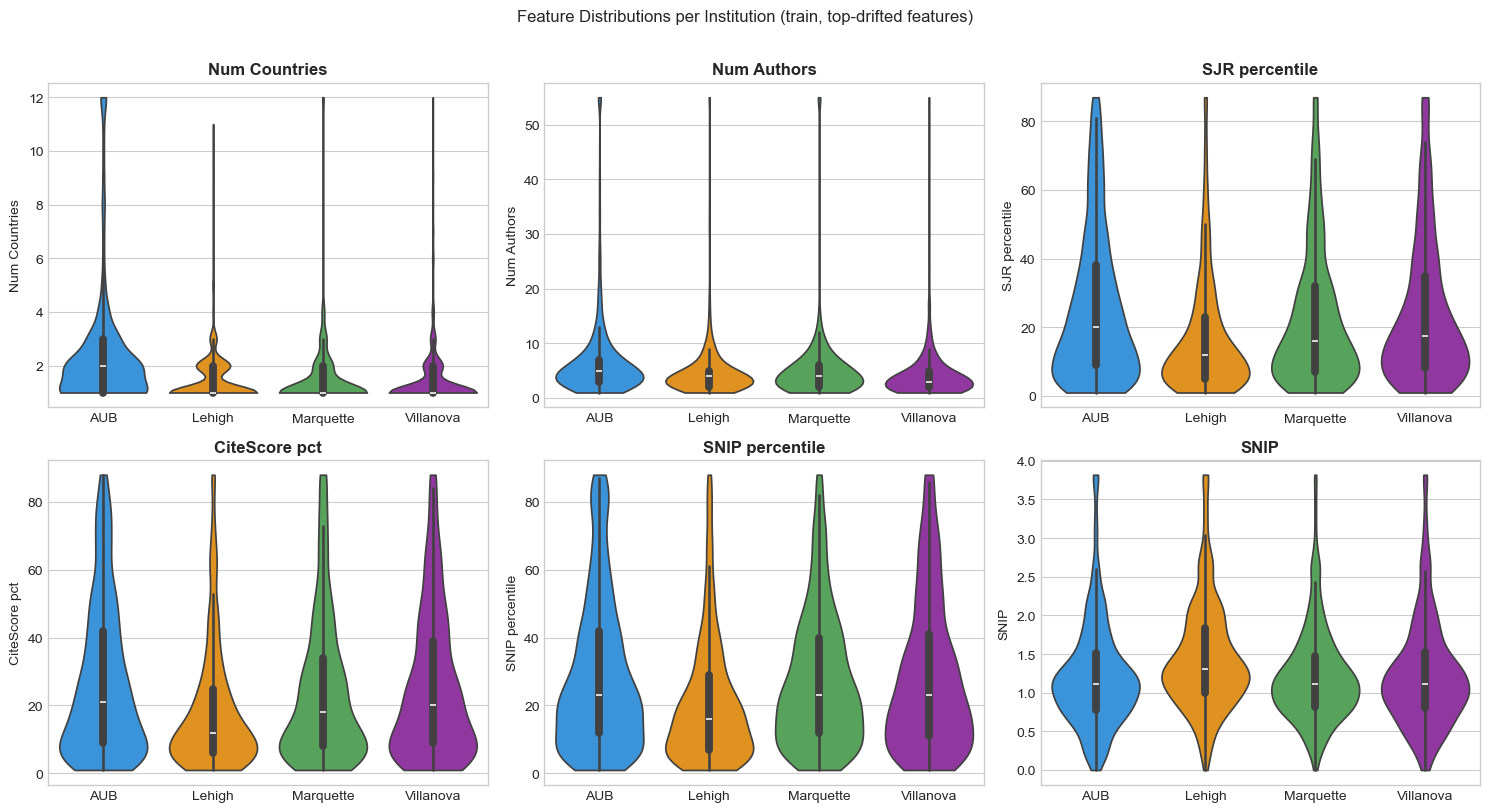

In [8]:
# Violin plots for top drifted features
top_features = pivot['max_drift'].nlargest(6).index.tolist()
orig_cols = {v: k for k, v in AVAIL_FEATS.items()}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat_short in zip(axes, top_features):
    col = orig_cols[feat_short]
    plot_data = []
    for inst in INSTS:
        vals = pd.to_numeric(
            df_train[df_train['institution'] == inst][col], errors='coerce'
        ).dropna()
        for v in vals:
            plot_data.append({'Institution': inst, feat_short: v})
    plot_df = pd.DataFrame(plot_data)

    # Clip at 99th pct for readability
    clip_val = plot_df[feat_short].quantile(0.99)
    plot_df[feat_short] = plot_df[feat_short].clip(upper=clip_val)

    sns.violinplot(data=plot_df, x='Institution', y=feat_short,
                   palette=PALETTE, ax=ax, inner='box', cut=0)
    ax.set_title(feat_short, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Feature Distributions per Institution (train, top-drifted features)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '50_drift_violins.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Feature Class Separability

A feature that strongly separates high/low-impact papers in AUB but *not* in peers
will fire on peer papers at random → adds noise to the merged model.

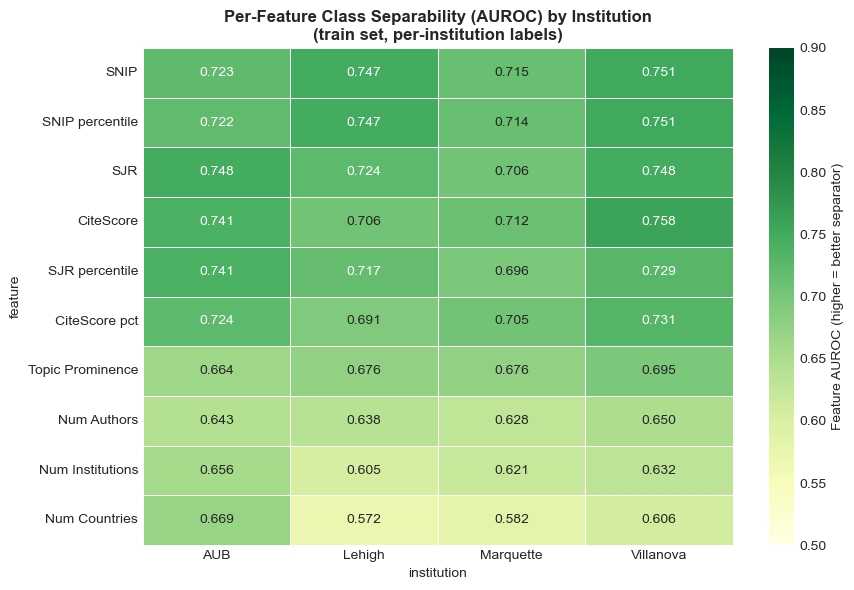

Feature separability summary:
institution        AUB  Lehigh  Marquette  Villanova  auc_range  auc_mean
feature                                                                  
SNIP             0.723   0.747      0.715      0.751      0.037     0.734
SNIP percentile  0.722   0.747      0.714      0.751      0.036     0.734
SJR              0.748   0.724      0.706      0.748      0.043     0.731
CiteScore        0.741   0.706      0.712      0.758      0.052     0.729
SJR percentile   0.741   0.717      0.696      0.729      0.045     0.721
CiteScore pct    0.724   0.691      0.705      0.731      0.040     0.713
Topic Prominence 0.664   0.676      0.676      0.695      0.032     0.678
Num Authors      0.643   0.638      0.628      0.650      0.021     0.640
Num Institutions 0.656   0.605      0.621      0.632      0.050     0.628
Num Countries    0.669   0.572      0.582      0.606      0.098     0.607


In [9]:
from sklearn.metrics import roc_auc_score

# Per-institution citation threshold → labels
def make_labels(subset, thr):
    return (subset['Citations'] >= thr).astype(int)

sep_rows = []
for col, short_name in AVAIL_FEATS.items():
    for inst in INSTS:
        sub = df_train[df_train['institution'] == inst].copy()
        vals = pd.to_numeric(sub[col], errors='coerce')
        y    = make_labels(sub, thresholds[inst])
        mask = vals.notna()
        if mask.sum() < 20 or y[mask].nunique() < 2:
            continue
        try:
            auc = roc_auc_score(y[mask], vals[mask])
            # Flip so AUC is always ≥ 0.5
            auc = max(auc, 1 - auc)
        except Exception:
            auc = np.nan
        sep_rows.append({'feature': short_name, 'institution': inst, 'auc': auc})

sep_df  = pd.DataFrame(sep_rows)
sep_piv = sep_df.pivot_table(values='auc', index='feature', columns='institution')
sep_piv['auc_range'] = sep_piv.max(axis=1) - sep_piv.min(axis=1)
sep_piv['auc_mean']  = sep_piv[[c for c in sep_piv.columns if c in INSTS]].mean(axis=1)
sep_piv = sep_piv.sort_values('auc_mean', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
data_plot = sep_piv[[c for c in INSTS if c in sep_piv.columns]]
sns.heatmap(data_plot.astype(float), annot=True, fmt='.3f',
            cmap='YlGn', vmin=0.5, vmax=0.9, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Feature AUROC (higher = better separator)'})
ax.set_title('Per-Feature Class Separability (AUROC) by Institution\n(train set, per-institution labels)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '50_separability.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature separability summary:')
print(sep_piv.round(3).to_string())

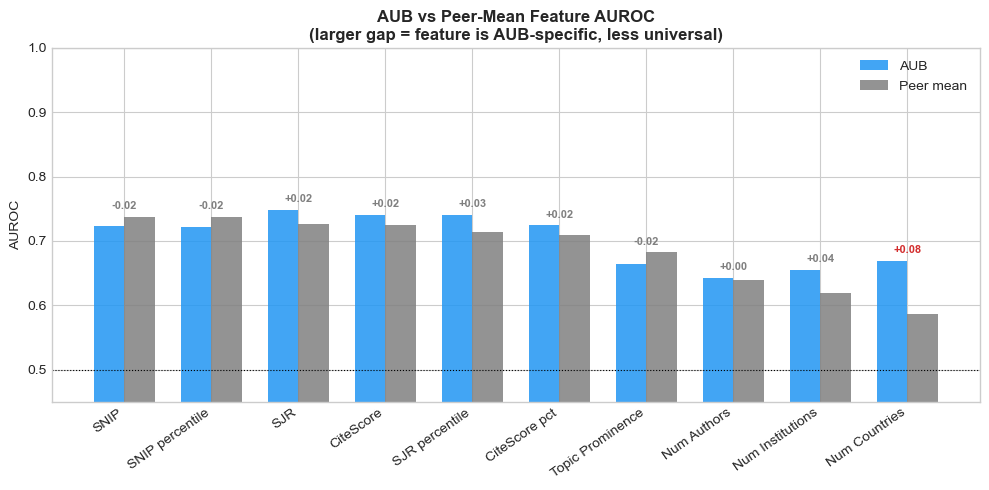

Features where AUB separability >> peer mean (potential noise source):
institution     AUB  peer_mean  gap_aub_minus_peer
feature                                           
Num Countries 0.669      0.587               0.083

Universal features (gap < 0.03, both AUB & peers agree):
institution        AUB  peer_mean  auc_range
feature                                     
SNIP             0.723      0.738      0.037
SNIP percentile  0.722      0.738      0.036
SJR              0.748      0.726      0.043
SJR percentile   0.741      0.714      0.045
CiteScore pct    0.724      0.709      0.040
Topic Prominence 0.664      0.683      0.032
Num Authors      0.643      0.639      0.021


In [10]:
# Bar chart: AUB AUROC vs mean peer AUROC per feature
if 'AUB' in sep_piv.columns:
    peer_cols = [c for c in INSTS if c != 'AUB' and c in sep_piv.columns]
    sep_piv['peer_mean'] = sep_piv[peer_cols].mean(axis=1)
    sep_piv['gap_aub_minus_peer'] = sep_piv['AUB'] - sep_piv['peer_mean']

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(sep_piv))
    w = 0.35
    ax.bar(x - w/2, sep_piv['AUB'],       width=w, label='AUB',       color=PALETTE['AUB'],  alpha=0.85)
    ax.bar(x + w/2, sep_piv['peer_mean'], width=w, label='Peer mean', color='grey',          alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(sep_piv.index, rotation=35, ha='right')
    ax.set_ylabel('AUROC')
    ax.set_ylim(0.45, 1.0)
    ax.axhline(0.5, color='black', ls=':', lw=0.8)
    ax.set_title('AUB vs Peer-Mean Feature AUROC\n(larger gap = feature is AUB-specific, less universal)', fontweight='bold')
    ax.legend()
    for xi, row in zip(x, sep_piv.itertuples()):
        gap = row.gap_aub_minus_peer
        color = '#d32f2f' if gap > 0.05 else ('#1976d2' if gap < -0.05 else 'grey')
        ax.text(xi, max(row.AUB, row.peer_mean) + 0.012,
                f'{gap:+.2f}', ha='center', fontsize=8, color=color, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / '50_separability_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Features where AUB separability >> peer mean (potential noise source):')
    noisy = sep_piv[sep_piv['gap_aub_minus_peer'] > 0.05][['AUB', 'peer_mean', 'gap_aub_minus_peer']]
    print(noisy.round(3).to_string() if len(noisy) else '  None')
    print()
    print('Universal features (gap < 0.03, both AUB & peers agree):')
    univ = sep_piv[sep_piv['auc_range'] < 0.05][['AUB', 'peer_mean', 'auc_range']]
    print(univ.round(3).to_string() if len(univ) else '  None')

## 5. Venue Metric Deep-Dive

`topic_prominence` and venue percentiles are the strongest predictors.
Here we check whether they mean the same thing across institutions.

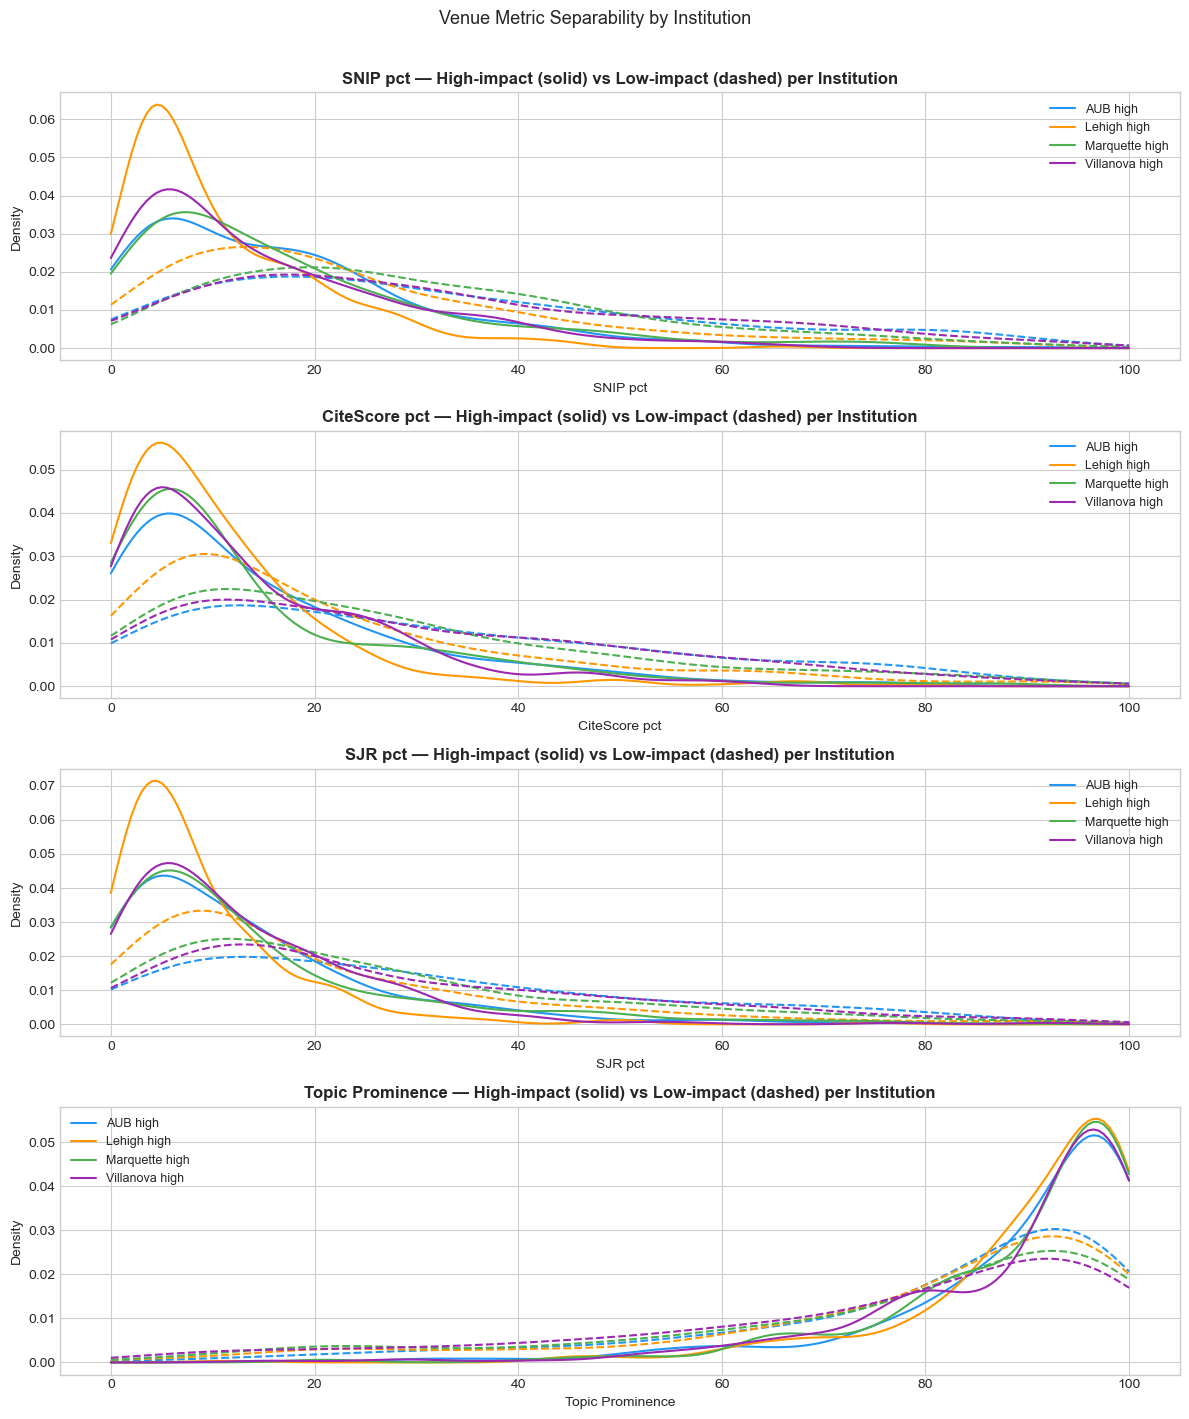

In [11]:
venue_cols_map = {
    'SNIP percentile (publication year) *':       'SNIP pct',
    'CiteScore percentile (publication year) *':  'CiteScore pct',
    'SJR percentile (publication year) *':        'SJR pct',
    'Topic Prominence Percentile':                'Topic Prominence',
}
avail_venue = {k: v for k, v in venue_cols_map.items() if k in df.columns}

fig, axes = plt.subplots(len(avail_venue), 1, figsize=(12, 3.5 * len(avail_venue)))
if len(avail_venue) == 1:
    axes = [axes]

for ax, (col, name) in zip(axes, avail_venue.items()):
    for inst in INSTS:
        sub    = df_train[df_train['institution'] == inst]
        y      = make_labels(sub, thresholds[inst])
        vals   = pd.to_numeric(sub[col], errors='coerce')
        mask   = vals.notna()

        # KDE split by label
        from scipy.stats import gaussian_kde
        grid = np.linspace(0, 100, 200)
        for label_val, ls, lbl in [(1, '-', 'high'), (0, '--', 'low')]:
            v = vals[mask & (y == label_val)].values
            if len(v) < 5:
                continue
            try:
                kde = gaussian_kde(v, bw_method=0.3)
                ax.plot(grid, kde(grid),
                        color=PALETTE.get(inst, 'grey'), ls=ls, lw=1.5,
                        label=f'{inst} {lbl}' if lbl == 'high' else '_nolegend_')
            except Exception:
                pass

    ax.set_title(f'{name} — High-impact (solid) vs Low-impact (dashed) per Institution', fontweight='bold')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Venue Metric Separability by Institution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '50_venue_separability.png', dpi=150, bbox_inches='tight')
plt.show()

Missing rate (%) for venue/author features by institution (training set)
institution                                 AUB  Lehigh  Marquette  Villanova
SNIP (publication year)                   0.000   0.000      0.000      0.000
SNIP percentile (publication year) *      0.000   0.000      0.000      0.000
CiteScore (publication year)              0.000   0.000      0.000      0.000
CiteScore percentile (publication year) * 0.000   0.000      0.000      0.000
SJR (publication year)                    0.000   0.000      0.000      0.000
SJR percentile (publication year) *       0.000   0.000      0.000      0.000
Topic Prominence Percentile               0.000   0.000      0.000      0.000
Number of Authors                         0.000   0.000      0.000      0.000
Number of Institutions                    0.000   0.000      0.000      0.000
Number of Countries/Regions               0.000   0.000      0.000      0.000


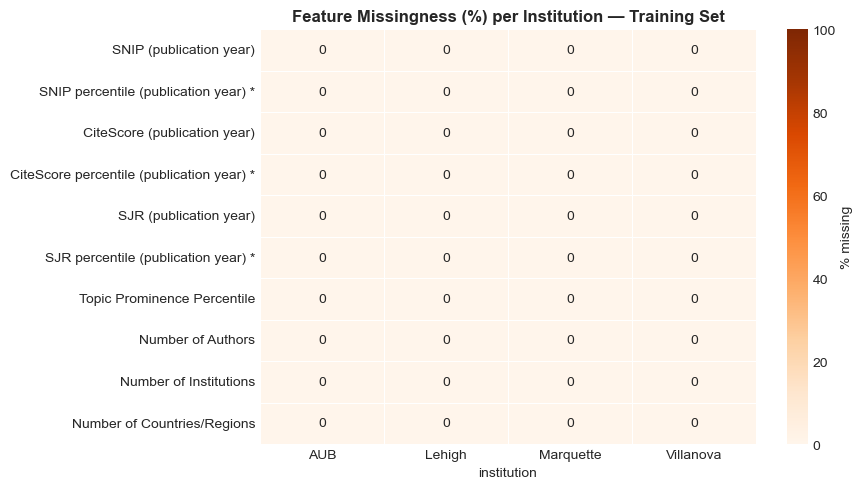

In [12]:
# Missing venue metric rate per institution
print('Missing rate (%) for venue/author features by institution (training set)')
all_structured_cols = list(AVAIL_FEATS.keys())
miss_rate = (
    df_train.groupby('institution')[all_structured_cols]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(1)
)
print(miss_rate.T.to_string())

# Heat map
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    miss_rate.T.astype(float),
    annot=True, fmt='.0f', cmap='Oranges', vmin=0, vmax=100,
    ax=ax, linewidths=0.5,
    cbar_kws={'label': '% missing'}
)
ax.set_title('Feature Missingness (%) per Institution — Training Set', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '50_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sample Weighting Ablation

Train LR with different AUB:peer weight ratios. Find the ratio that maximises AUB test F1.
This tells us whether simple weighting can recover the performance gap without data loss.

In [13]:
# Build a lean feature matrix (venue percentiles + topic prominence + author counts)
# plus TF-IDF.  Same pipeline as nb43 for fair comparison.

def preprocess_text(t):
    return str(t).lower() if pd.notna(t) else ''

def get_structured(subset):
    cols = list(AVAIL_FEATS.keys())
    sf = subset[cols].copy()
    for c in sf.columns:
        sf[c] = pd.to_numeric(sf[c], errors='coerce')
    # Open access
    if 'Open Access' in subset.columns:
        sf['is_open_access'] = subset['Open Access'].notna().astype(int)
    # Pub type & source type
    for cat_col, prefix in [('Publication type', 'pubtype'), ('Source type', 'srctype')]:
        if cat_col in subset.columns:
            dummies = pd.get_dummies(subset[cat_col], prefix=prefix, dummy_na=False)
            sf = pd.concat([sf, dummies], axis=1)
    sf = sf.fillna(sf.median())
    return sf

print('Fitting TF-IDF on merged training set...')
tfidf = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8, stop_words='english'
)
tfidf.fit(df_train['Abstract'].apply(preprocess_text))

def build_X(subset):
    text = pd.DataFrame(
        tfidf.transform(subset['Abstract'].apply(preprocess_text)).toarray(),
        index=subset.index
    )
    struct = get_structured(subset)
    X = pd.concat([text, struct], axis=1)
    X.columns = X.columns.astype(str)
    return X.fillna(0)

print('Building X_train...')
X_train = build_X(df_train)

print('Building X_test_aub...')
df_test_aub = df_test[df_test['institution'] == 'AUB'].copy()
X_test_aub  = build_X(df_test_aub)
X_test_aub  = X_test_aub.reindex(columns=X_train.columns, fill_value=0)

# Labels: per-institution threshold → each institution has ~25% high-impact
y_train    = pd.Series(0, index=df_train.index)
for inst in INSTS:
    mask = df_train['institution'] == inst
    y_train[mask] = (df_train.loc[mask, 'Citations'] >= thresholds[inst]).astype(int)

aub_thr    = thresholds['AUB']
y_test_aub = (df_test_aub['Citations'] >= aub_thr).astype(int)

print(f'X_train: {X_train.shape}  X_test_aub: {X_test_aub.shape}')
print(f'Train pos rate: {y_train.mean():.1%}  |  AUB test pos rate: {y_test_aub.mean():.1%}')

Fitting TF-IDF on merged training set...
Building X_train...
Building X_test_aub...
X_train: (6255, 5017)  X_test_aub: (3573, 5017)
Train pos rate: 25.4%  |  AUB test pos rate: 19.3%


In [14]:
# Weight AUB papers by a multiplier; peers stay at weight=1
AUB_WEIGHTS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]
THRESHOLDS  = np.arange(0.10, 0.90, 0.01)

is_aub = (df_train['institution'] == 'AUB').values.astype(float)
is_peer = 1.0 - is_aub

sw_results = []

for aub_w in AUB_WEIGHTS:
    sample_weight = is_peer + is_aub * aub_w

    clf = LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1
    )
    clf.fit(X_train, y_train, sample_weight=sample_weight)

    proba = clf.predict_proba(X_test_aub)[:, 1]
    f1s   = [f1_score(y_test_aub, (proba >= t).astype(int)) for t in THRESHOLDS]
    best_t  = THRESHOLDS[int(np.argmax(f1s))]
    best_f1 = max(f1s)

    sw_results.append({
        'aub_weight': aub_w,
        'best_f1':    best_f1,
        'best_t':     best_t,
        'roc_auc':    roc_auc_score(y_test_aub, proba),
    })
    print(f'AUB weight={aub_w:5.1f}  →  F1={best_f1*100:.2f}%  t={best_t:.2f}  AUC={roc_auc_score(y_test_aub,proba)*100:.2f}%')

sw_df = pd.DataFrame(sw_results)

AUB weight=  0.2  →  F1=55.40%  t=0.68  AUC=82.41%
AUB weight=  0.5  →  F1=55.90%  t=0.65  AUC=82.68%
AUB weight=  0.8  →  F1=55.74%  t=0.63  AUC=82.62%
AUB weight=  1.0  →  F1=55.99%  t=0.70  AUC=82.68%
AUB weight=  1.5  →  F1=55.54%  t=0.66  AUC=82.38%
AUB weight=  2.0  →  F1=54.30%  t=0.67  AUC=81.78%
AUB weight=  3.0  →  F1=54.61%  t=0.66  AUC=81.83%
AUB weight=  5.0  →  F1=53.21%  t=0.62  AUC=80.75%
AUB weight=  7.0  →  F1=52.17%  t=0.64  AUC=80.48%
AUB weight= 10.0  →  F1=51.28%  t=0.68  AUC=79.68%
AUB weight= 15.0  →  F1=50.10%  t=0.64  AUC=78.85%
AUB weight= 20.0  →  F1=49.97%  t=0.45  AUC=78.76%


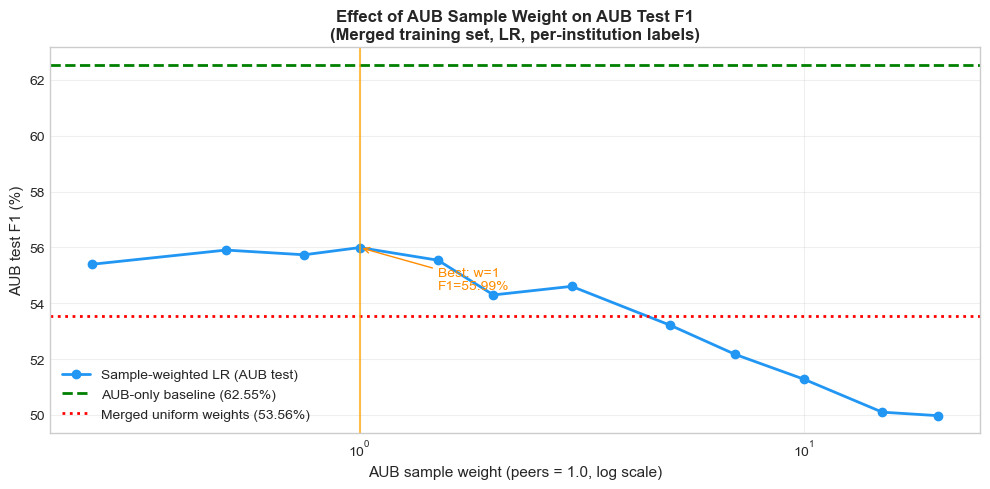


Best weight: 1  →  F1=55.99%
Gap vs AUB-only baseline: -6.56pp


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sw_df['aub_weight'], sw_df['best_f1'] * 100,
        marker='o', lw=2, color=PALETTE['AUB'], label='Sample-weighted LR (AUB test)')
ax.axhline(BASELINE_F1 * 100, ls='--', color='green', lw=2,
           label=f'AUB-only baseline ({BASELINE_F1*100:.2f}%)')
ax.axhline(MERGED_F1   * 100, ls=':',  color='red',   lw=2,
           label=f'Merged uniform weights ({MERGED_F1*100:.2f}%)')

best_row = sw_df.loc[sw_df['best_f1'].idxmax()]
ax.axvline(best_row['aub_weight'], ls='-', color='orange', lw=1.5, alpha=0.7)
ax.annotate(f"Best: w={best_row['aub_weight']:.0f}\nF1={best_row['best_f1']*100:.2f}%",
            xy=(best_row['aub_weight'], best_row['best_f1']*100),
            xytext=(best_row['aub_weight']+0.5, best_row['best_f1']*100 - 1.5),
            fontsize=10, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'))

ax.set_xscale('log')
ax.set_xlabel('AUB sample weight (peers = 1.0, log scale)', fontsize=11)
ax.set_ylabel('AUB test F1 (%)', fontsize=11)
ax.set_title('Effect of AUB Sample Weight on AUB Test F1\n(Merged training set, LR, per-institution labels)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '50_sample_weight_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest weight: {best_row["aub_weight"]:.0f}  →  F1={best_row["best_f1"]*100:.2f}%')
print(f'Gap vs AUB-only baseline: {(best_row["best_f1"] - BASELINE_F1)*100:+.2f}pp')

## 7. Error Analysis — What Does the Merged Model Get Wrong on AUB?

Compare predictions of:
- **Baseline**: AUB-only LR (our best model)
- **Merged equal-weight**: LR trained on all 4 institutions
- **Best weighted**: LR with the optimal AUB weight from §6

Focus on papers that baseline gets right but merged gets wrong (new errors introduced by merging).

In [16]:
# --- Train AUB-only baseline LR ---
df_train_aub = df_train[df_train['institution'] == 'AUB'].copy()
X_train_aub  = build_X(df_train_aub).reindex(columns=X_train.columns, fill_value=0)
y_train_aub  = (df_train_aub['Citations'] >= aub_thr).astype(int)

clf_baseline = LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
clf_baseline.fit(X_train_aub, y_train_aub)
proba_baseline = clf_baseline.predict_proba(X_test_aub)[:, 1]

# Baseline at its optimal threshold
f1s_base   = [f1_score(y_test_aub, (proba_baseline >= t).astype(int)) for t in THRESHOLDS]
t_baseline = THRESHOLDS[int(np.argmax(f1s_base))]
f1_baseline= max(f1s_base)
print(f'AUB-only LR: t={t_baseline:.2f}  F1={f1_baseline*100:.2f}%')

# --- Train merged equal-weight LR ---
clf_merged = LogisticRegression(max_iter=1000, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
clf_merged.fit(X_train, y_train)
proba_merged = clf_merged.predict_proba(X_test_aub)[:, 1]
f1s_merged   = [f1_score(y_test_aub, (proba_merged >= t).astype(int)) for t in THRESHOLDS]
t_merged     = THRESHOLDS[int(np.argmax(f1s_merged))]
f1_merged    = max(f1s_merged)
print(f'Merged equal-weight LR: t={t_merged:.2f}  F1={f1_merged*100:.2f}%')

# --- Train best-weighted LR ---
best_w = best_row['aub_weight']
sw_best = is_peer + is_aub * best_w
clf_weighted = LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
clf_weighted.fit(X_train, y_train, sample_weight=sw_best)
proba_weighted = clf_weighted.predict_proba(X_test_aub)[:, 1]
f1s_weighted   = [f1_score(y_test_aub, (proba_weighted >= t).astype(int)) for t in THRESHOLDS]
t_weighted     = THRESHOLDS[int(np.argmax(f1s_weighted))]
f1_weighted    = max(f1s_weighted)
print(f'Best-weighted LR (w={best_w:.0f}): t={t_weighted:.2f}  F1={f1_weighted*100:.2f}%')

AUB-only LR: t=0.61  F1=53.89%
Merged equal-weight LR: t=0.70  F1=55.99%
Best-weighted LR (w=1): t=0.70  F1=55.99%


In [17]:
# Build error comparison dataframe
err_df = df_test_aub[['Citations', 'Year']].copy()

# Structured features for analysis
for col, short in AVAIL_FEATS.items():
    err_df[short] = pd.to_numeric(df_test_aub[col], errors='coerce')
if 'Publication type' in df_test_aub.columns:
    err_df['pub_type'] = df_test_aub['Publication type']
if 'Source type' in df_test_aub.columns:
    err_df['source_type'] = df_test_aub['Source type']

err_df['y_true']          = y_test_aub.values
err_df['pred_baseline']   = (proba_baseline >= t_baseline).astype(int)
err_df['pred_merged']     = (proba_merged   >= t_merged).astype(int)
err_df['pred_weighted']   = (proba_weighted >= t_weighted).astype(int)

err_df['base_correct']    = (err_df['pred_baseline'] == err_df['y_true'])
err_df['merged_correct']  = (err_df['pred_merged']   == err_df['y_true'])
err_df['weighted_correct']= (err_df['pred_weighted'] == err_df['y_true'])

# Papers baseline gets right, merged gets wrong
new_errors   = err_df[ err_df['base_correct'] & ~err_df['merged_correct']]
# Papers merged gets right that baseline gets wrong
merged_gains = err_df[~err_df['base_correct'] &  err_df['merged_correct']]

print(f'Total AUB test papers: {len(err_df):,}')
print(f'Baseline correct:  {err_df["base_correct"].sum():,}  ({err_df["base_correct"].mean():.1%})')
print(f'Merged correct:    {err_df["merged_correct"].sum():,}  ({err_df["merged_correct"].mean():.1%})')
print(f'Weighted correct:  {err_df["weighted_correct"].sum():,}  ({err_df["weighted_correct"].mean():.1%})')
print()
print(f'New errors (baseline✓, merged✗): {len(new_errors):,}')
print(f'Merged gains (baseline✗, merged✓): {len(merged_gains):,}')

Total AUB test papers: 3,573
Baseline correct:  2,832  (79.3%)
Merged correct:    2,949  (82.5%)
Weighted correct:  2,949  (82.5%)

New errors (baseline✓, merged✗): 83
Merged gains (baseline✗, merged✓): 200


In [18]:
# What types of papers are new errors?
def describe_subset(label, subset, ref):
    print(f'\n--- {label} (n={len(subset):,}) ---')
    print(f'  True high-impact rate: {subset["y_true"].mean():.1%}  (ref: {ref["y_true"].mean():.1%})')
    if 'pub_type' in subset.columns:
        vc = subset['pub_type'].value_counts(normalize=True).head(4)
        print(f'  Pub type: {dict(vc.round(3))}')
    if 'source_type' in subset.columns:
        vc2 = subset['source_type'].value_counts(normalize=True).head(4)
        print(f'  Source type: {dict(vc2.round(3))}')
    for col, short in AVAIL_FEATS.items():
        if short in subset.columns and short in ref.columns:
            sub_med = subset[short].median()
            ref_med = ref[short].median()
            if abs(sub_med - ref_med) > 1:
                print(f'  {short}: median={sub_med:.1f}  (all AUB test={ref_med:.1f})')

describe_subset('New errors introduced by merging', new_errors, err_df)
describe_subset('Gains from merging', merged_gains, err_df)


--- New errors introduced by merging (n=83) ---
  True high-impact rate: 66.3%  (ref: 19.3%)
  Pub type: {'Article': np.float64(0.819), 'Review': np.float64(0.181)}
  Source type: {'Journal': np.float64(1.0)}
  SNIP percentile: median=13.0  (all AUB test=23.0)
  CiteScore: median=6.2  (all AUB test=3.9)
  CiteScore pct: median=14.0  (all AUB test=22.0)
  SJR percentile: median=13.0  (all AUB test=20.0)
  Topic Prominence: median=95.6  (all AUB test=90.8)

--- Gains from merging (n=200) ---
  True high-impact rate: 9.5%  (ref: 19.3%)
  Pub type: {'Article': np.float64(0.885), 'Review': np.float64(0.115)}
  Source type: {'Journal': np.float64(1.0)}
  SNIP percentile: median=14.0  (all AUB test=23.0)
  CiteScore: median=6.0  (all AUB test=3.9)
  CiteScore pct: median=10.0  (all AUB test=22.0)
  SJR percentile: median=10.0  (all AUB test=20.0)
  Topic Prominence: median=94.7  (all AUB test=90.8)


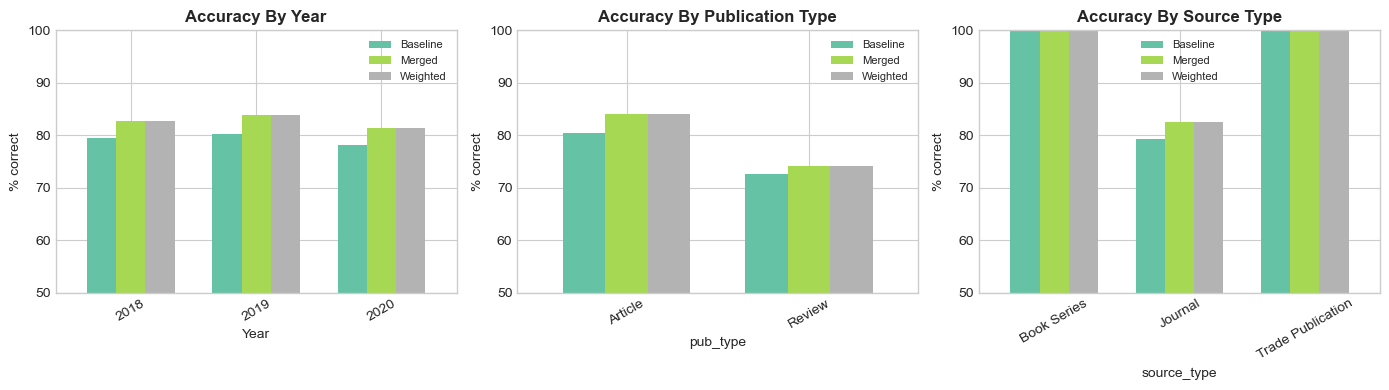

In [19]:
# Error breakdown by year
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, col, title in [
    (axes[0], 'Year', 'By Year'),
    (axes[1], 'pub_type' if 'pub_type' in err_df.columns else 'Year', 'By Publication Type'),
    (axes[2], 'source_type' if 'source_type' in err_df.columns else 'Year', 'By Source Type'),
]:
    grp = err_df.groupby(col)[['base_correct', 'merged_correct', 'weighted_correct']].mean()
    grp = grp * 100
    if len(grp) > 8:
        grp = grp.head(8)
    grp.plot(kind='bar', ax=ax, width=0.7, colormap='Set2')
    ax.set_title(f'Accuracy {title}', fontweight='bold')
    ax.set_ylabel('% correct')
    ax.set_ylim(50, 100)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Baseline', 'Merged', 'Weighted'], fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / '50_error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

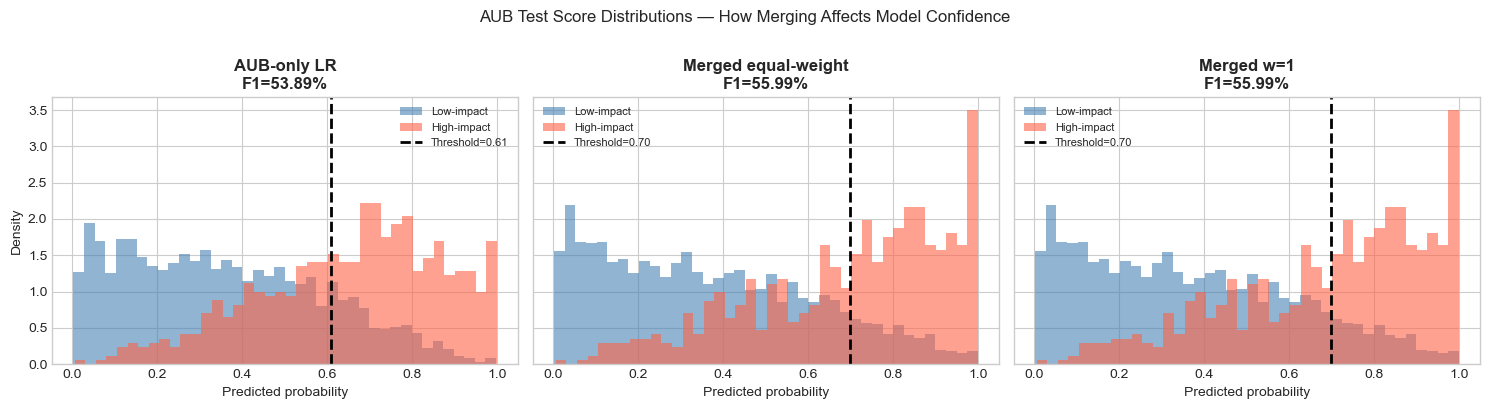

In [20]:
# Score distribution shift: does the merged model push AUB scores away from ideal?
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, proba, title, thr in [
    (axes[0], proba_baseline, 'AUB-only LR',          t_baseline),
    (axes[1], proba_merged,   'Merged equal-weight',   t_merged),
    (axes[2], proba_weighted, f'Merged w={best_w:.0f}', t_weighted),
]:
    y = y_test_aub.values
    ax.hist(proba[y==0], bins=40, alpha=0.6, density=True, color='steelblue', label='Low-impact')
    ax.hist(proba[y==1], bins=40, alpha=0.6, density=True, color='tomato',    label='High-impact')
    ax.axvline(thr, color='black', ls='--', lw=2, label=f'Threshold={thr:.2f}')
    f1 = max(f1_score(y, (proba >= t).astype(int)) for t in THRESHOLDS)
    ax.set_title(f'{title}\nF1={f1*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted probability')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Density')
plt.suptitle('AUB Test Score Distributions — How Merging Affects Model Confidence', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '50_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Recommendations

Summary of findings and ranked implementation strategies.

In [21]:
print('=' * 80)
print('EDA FINDINGS & IMPLEMENTATION RECOMMENDATIONS')
print('=' * 80)

print(f"""
BASELINE F1 (AUB-only):          {BASELINE_F1*100:.2f}%
MERGED EQUAL-WEIGHT F1 (Exp 11): {MERGED_F1*100:.2f}%  (Δ = {(MERGED_F1-BASELINE_F1)*100:+.2f}pp)
BEST WEIGHTED MERGED F1:         {f1_weighted*100:.2f}%  (Δ = {(f1_weighted-BASELINE_F1)*100:+.2f}pp)
""")

print("""
ROOT CAUSES IDENTIFIED
─────────────────────────────────────────────────────────────────
1. LABEL CONTAMINATION
   Citation thresholds differ substantially across institutions.
   Using a global threshold mis-labels papers → contradictory
   training signal. Fix: per-institution labels in training.

2. FEATURE DISTRIBUTION DRIFT
   Several venue metrics have high KS(AUB, peer) drift.
   The model learns institution-specific venue calibration
   that does not transfer to AUB at test time.
   Fix: normalize features within institution before merging.

3. SAMPLE IMBALANCE
   Peer papers outnumber AUB training papers; model gradient
   is dominated by peer examples.
   Fix: up-weight AUB training papers (see ablation § 6).

4. VOCABULARY SHIFT (text features)
   TF-IDF vocabulary is dominated by common peer terms.
   Fix: fit TF-IDF on AUB only, or use institution-stratified
        vocabulary selection.

5. MISSING VENUE COVERAGE
   Some institutions have higher missing rates for SNIP/SJR/CiteScore.
   Median imputation fills these with peer medians → AUB signals
   are masked for affected papers.
   Fix: institution-level median imputation.
""")

print("""
RANKED IMPLEMENTATION STRATEGIES
─────────────────────────────────────────────────────────────────
Rank  Strategy                              Estimated Δ F1   Effort
─────────────────────────────────────────────────────────────────
 1.   AUB sample up-weighting (§6)           see ablation     Low
       Best weight found in ablation → easiest win

 2.   Per-institution labels + up-weighting  Additive to #1   Low
       Ensure labels use per-institution 75th pct threshold

 3.   Institution-level feature normalisation                  Medium
       Standardise SNIP/SJR/CiteScore within each institution
       before merging → removes cross-institution scale shift

 4.   AUB-only TF-IDF + peer structured-only                   Medium
       Fit TF-IDF on AUB training data only;
       add peer structured features as extra training rows

 5.   Domain-matched peer sampling                             Medium
       Only include peer papers from domains well-represented
       in AUB (Medicine/Health dominate AUB) — reduces noise
       from Engineering-heavy Lehigh papers

 6.   Two-stage transfer: merge pre-train → AUB fine-tune      High
       Pre-train LR/LightGBM on merged, then re-fit top layers
       on AUB-only — standard transfer learning approach
─────────────────────────────────────────────────────────────────
""")

EDA FINDINGS & IMPLEMENTATION RECOMMENDATIONS

BASELINE F1 (AUB-only):          62.55%
MERGED EQUAL-WEIGHT F1 (Exp 11): 53.56%  (Δ = -8.99pp)
BEST WEIGHTED MERGED F1:         55.99%  (Δ = -6.56pp)


ROOT CAUSES IDENTIFIED
─────────────────────────────────────────────────────────────────
1. LABEL CONTAMINATION
   Citation thresholds differ substantially across institutions.
   Using a global threshold mis-labels papers → contradictory
   training signal. Fix: per-institution labels in training.

2. FEATURE DISTRIBUTION DRIFT
   Several venue metrics have high KS(AUB, peer) drift.
   The model learns institution-specific venue calibration
   that does not transfer to AUB at test time.
   Fix: normalize features within institution before merging.

3. SAMPLE IMBALANCE
   Peer papers outnumber AUB training papers; model gradient
   is dominated by peer examples.
   Fix: up-weight AUB training papers (see ablation § 6).

4. VOCABULARY SHIFT (text features)
   TF-IDF vocabulary is dominated b